# Heart Disease Prediction — Data Preparation & EDA

## 1.1 Problem Statement

This is a binary classification problem: given a patient's clinical 
measurements, predict whether they currently have heart disease (1) or 
not (0). Because false negatives (missing a real case) carry greater 
real-world risk than false positives in a medical context, model 
evaluation will prioritize recall alongside accuracy.

**Dataset:** [Heart Failure Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) 
(918 patients, 11 clinical features)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score
import joblib


In [2]:
df = pd.read_csv('../data/heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [4]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### 1.2 Data Cleaning
**Cholesterol and RestingBP contain disguised missing values encoded as 0,which is not physiologically possible. isnull() does not catch these.**

In [5]:
print("Zero values — Cholesterol:", (df['Cholesterol'] == 0).sum())
print("Zero values — RestingBP:", (df['RestingBP'] == 0).sum())

Zero values — Cholesterol: 172
Zero values — RestingBP: 1


In [6]:
# Checked whether missing Cholesterol values were randomly distributed 
# or correlated with the target — found a ~6x disparity between classes 
# (29.9% of HeartDisease=1 patients affected vs. 4.9% of HeartDisease=0), 
# indicating Missing Not At Random (MNAR) rather than random noise.
df.groupby('HeartDisease')['Cholesterol'].apply(lambda x: (x == 0).sum())

HeartDisease
0     20
1    152
Name: Cholesterol, dtype: int64

In [7]:
# Cholesterol: flag missingness before imputing (MNAR pattern above means 
# missingness itself may carry signal), then impute using the median of 
# valid readings only.
df['Cholesterol_missing'] = (df['Cholesterol'] == 0).astype(int)
median_cholesterol = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].median()
df['Cholesterol'] = df['Cholesterol'].replace(0, median_cholesterol)

# RestingBP: single affected row (0.1% of data) — simple median imputation 
# is proportional to the scale of the issue; no indicator column needed.
median_bp = df.loc[df['RestingBP'] != 0, 'RestingBP'].median()
df['RestingBP'] = df['RestingBP'].replace(0, median_bp)

**Known limitation:** Cholesterol imputation may dilute the true 
relationship between cholesterol and heart disease, since 88% of the 
imputed values belong to positive cases. Model-based imputation would 
be a stronger approach in a future iteration.

## 1.3 Exploratory Data Analysis

**Visualizing the Data**

**What we want to do here is that:**
Before building any model, we need to understand the shape of our target 
variable and how our features relate to it. This step helps us form 
early intuitions about what the model might learn, and helps us catch 
any surprises in the data before we commit to a modeling approach.

**Class Distribution**

Since this is a binary classification problem, the first thing we check 
is how balanced our two classes are — patients with heart disease (1) 
vs. patients without (0).

**Why this matters:** If one class dominates (e.g., 95% healthy, 5% sick), 
accuracy alone becomes a misleading metric — a model could achieve 95% 
accuracy by just always predicting "healthy" without learning anything 
useful. Understanding this now shapes how we evaluate our model later.

In [8]:
# Class balance — confirms a reasonably balanced target (~55%/45%), 
# supporting accuracy as a meaningful evaluation metric.
df['HeartDisease'].value_counts(normalize=True)

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

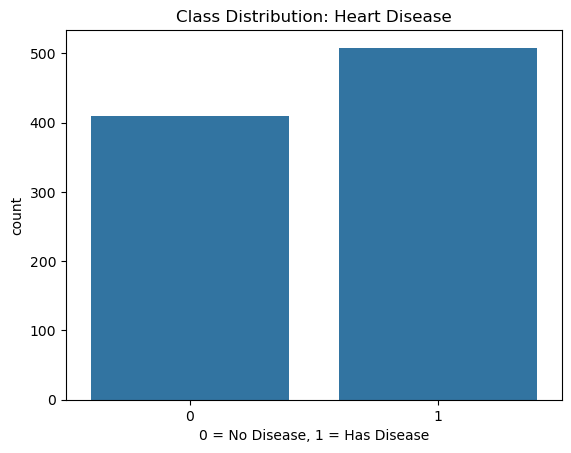

In [9]:
sns.countplot(data=df, x='HeartDisease')
plt.title('Class Distribution: Heart Disease')
plt.xlabel('0 = No Disease, 1 = Has Disease')
plt.show()

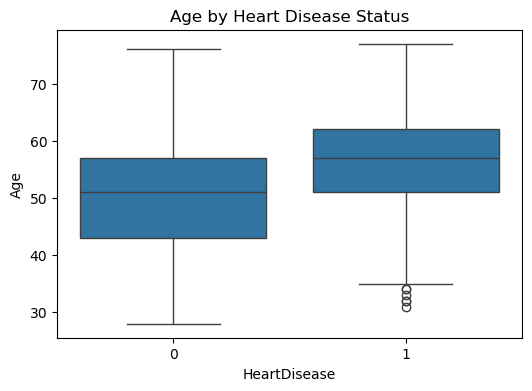

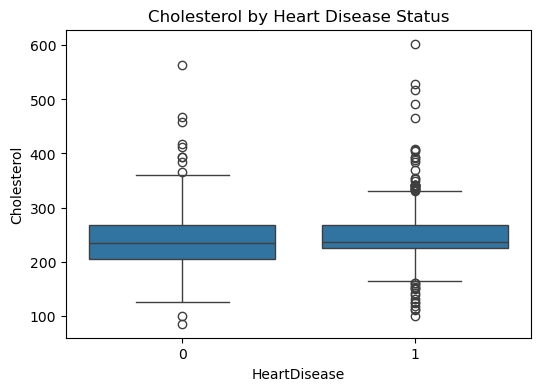

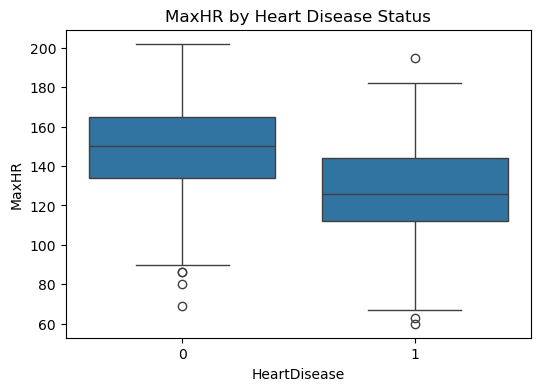

In [10]:
# Numeric feature distributions by class
for col in ['Age', 'Cholesterol', 'MaxHR']:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='HeartDisease', y=col)
    plt.title(f'{col} by Heart Disease Status')
    plt.show()

**Male patients in this dataset are considerably more likely to have heart disease, while female patients are considerably more likely to NOT have it.**

In [11]:
df["Sex"].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

**This dataset shows that it's heavily skewed toward male patients — roughly 4x more men than women.**

The model will see far more examples of male patients, in far more varied situations, than female patients. This means whatever pattern it learns about "Sex" is disproportionately driven by data from men.

**This is a subgroup performance gap**

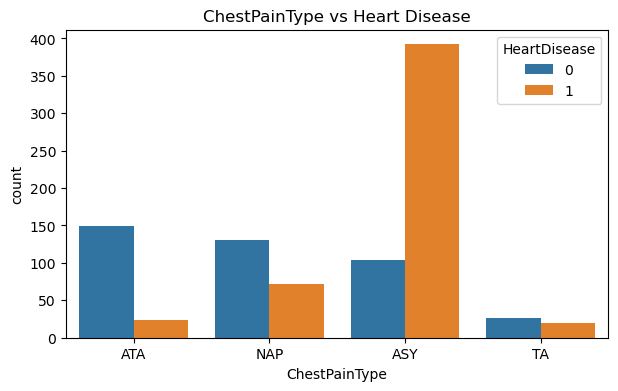

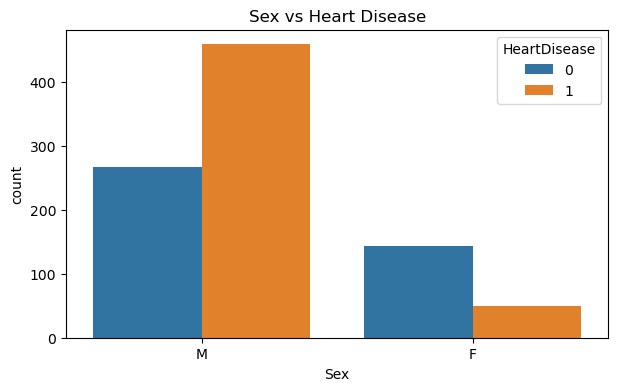

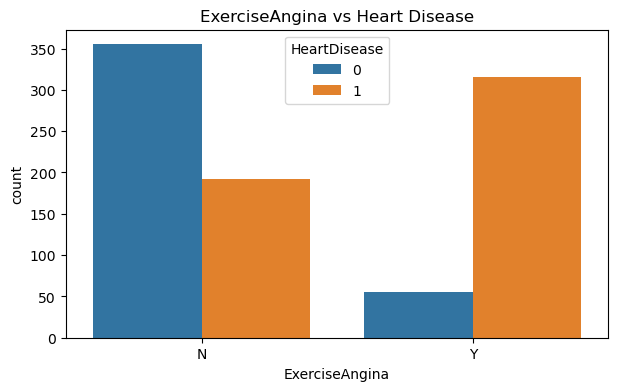

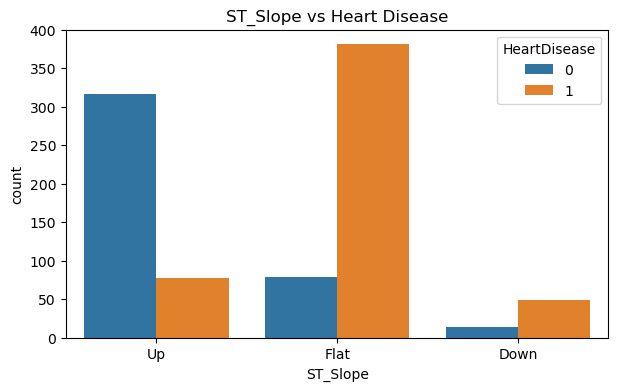

In [12]:
# Categorical feature distributions by class
for col in ['ChestPainType', 'Sex', 'ExerciseAngina', 'ST_Slope']:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=col, hue='HeartDisease')
    plt.title(f'{col} vs Heart Disease')
    plt.show()

**Key EDA findings:**
- **Strong signal:** MaxHR, ChestPainType (ASY), ExerciseAngina, 
  ST_Slope (Flat) — all show clear separation between classes and 
  align with established clinical patterns.
- **Weak signal:** Cholesterol shows minimal separation, likely 
  affected by imputation (see limitation above).
- **Class imbalance within a feature:** Sex is 79% male / 21% female. 
  While Sex shows a strong association with the target, this imbalance 
  means the model's understanding of female patients is based on a 
  smaller, less representative sample — flagged for subgroup evaluation 
  during model assessment.

## 1.4 Encoding Categorical Features

Before we can train a logistic regression model, every input must be 
numeric.

We use two different encoding strategies depending on the number of 
categories in each column:

- **Label Encoding** for binary categories (Sex, ExerciseAngina) — 
  simply mapping to 0/1, since there's no risk of implying a false order.
- **One-Hot Encoding** for categories with 3+ options (ChestPainType, 
  RestingECG, ST_Slope) — creating separate binary columns per category, 
  since assigning arbitrary numbers (0,1,2,3) would falsely imply ranking 
  that doesn't exist between them.

 with 
`drop_first=True` to avoid redundant, perfectly collinear columns.

In [13]:
df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})
df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y': 1, 'N': 0})

df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], 
                     drop_first=True)

## 1.5 Train/Test Split

Data is split 80/20, stratified on the target to preserve class balance 
across both sets.

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (734, 16)
Test set shape: (184, 16)


In [15]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTraining set class balance:")
print(y_train.value_counts(normalize=True))
print("\nTest set class balance:")
print(y_test.value_counts(normalize=True))

Training set shape: (734, 16)
Test set shape: (184, 16)

Training set class balance:
HeartDisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64

Test set class balance:
HeartDisease
1    0.554348
0    0.445652
Name: proportion, dtype: float64


## 1.6 Feature Scaling

Logistic regression's gradient descent is sensitive to feature scale - 
features with larger numeric ranges (e.g., Cholesterol: 0-600+) produce 
disproportionately large gradient updates compared to smaller-scale 
features (e.g., Sex: 0/1), causing inefficient, uneven convergence.

We standardize numeric features to mean=0, std=1 using scikit-learn's 
StandardScaler.

**Critical rule:** The scaler is fit ONLY on training data, then used 
to transform both train and test sets. Fitting on combined data would 
leak test set statistics into training, a form of data leakage that 
makes evaluation results artificially optimistic.

In [19]:
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

we Identified which columns actually need scaling.
Binary/one-hot columns (already 0/1) don't need scaling

In [20]:
# Fit the scaler using ONLY training data statistics (mean, std)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

In [21]:
# Transform test data using the SAME scaler 
# (fitted on train only)
X_test_scaled = X_test.copy()
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [22]:
# scaled training data should have mean ≈ 0, std ≈ 1
print(X_train_scaled[numeric_cols].describe().loc[['mean', 'std']])

               Age     RestingBP   Cholesterol         MaxHR       Oldpeak
mean  2.105491e-16 -6.389076e-16  7.502325e-17 -1.270555e-16  8.107351e-17
std   1.000682e+00  1.000682e+00  1.000682e+00  1.000682e+00  1.000682e+00


## 1.7: Model Training

In [23]:
# Initialized Logistic Regression with reproducible training
# Increased iteration limit to ensure convergence on encoded feature set
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train  )

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
print("model Training complete.")
print('Number of iterations:', model.n_iter_)

model Training complete.
Number of iterations: [17]


## 1.8: Starting To Make Predictions

In [25]:
# Generate class predictions and probability estimates on held-out test set
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

## 1.9: Model Evaluation

In [26]:
accuracy = accuracy_score(y_test, y_pred)
print(f"test Accuracy: {accuracy:.4f}")
cm = confusion_matrix(y_test, y_pred)
print(f'\nConfusion Matrix:\n{cm}')

test Accuracy: 0.8967

Confusion Matrix:
[[71 11]
 [ 8 94]]


In [27]:
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recal: {recall:.4f}")
print(f"f1-score: {f1:.4f}")

Precision: 0.8952
Recal: 0.9216
f1-score: 0.9082


In [28]:
# Lowering threshold below 0.5 to reduce false negatives.
# In this medical context, missing a positive case carries higher
# cost than a false alarm — recall is prioritized over precision.

thresholds = np.arange(0.30, 0.55, 0.01)
results = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    results.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t),
        'recall': recall_score(y_test, y_pred_t),
        'f1': f1_score(y_test, y_pred_t)
    })

results_df = pd.DataFrame(results)
print(results_df)

    threshold  precision    recall        f1
0        0.30   0.836207  0.950980  0.889908
1        0.31   0.850877  0.950980  0.898148
2        0.32   0.850877  0.950980  0.898148
3        0.33   0.850877  0.950980  0.898148
4        0.34   0.850877  0.950980  0.898148
5        0.35   0.850877  0.950980  0.898148
6        0.36   0.850877  0.950980  0.898148
7        0.37   0.850877  0.950980  0.898148
8        0.38   0.849558  0.941176  0.893023
9        0.39   0.857143  0.941176  0.897196
10       0.40   0.857143  0.941176  0.897196
11       0.41   0.857143  0.941176  0.897196
12       0.42   0.864865  0.941176  0.901408
13       0.43   0.864865  0.941176  0.901408
14       0.44   0.864865  0.941176  0.901408
15       0.45   0.864865  0.941176  0.901408
16       0.46   0.872727  0.941176  0.905660
17       0.47   0.871560  0.931373  0.900474
18       0.48   0.887850  0.931373  0.909091
19       0.49   0.887850  0.931373  0.909091
20       0.50   0.895238  0.921569  0.908213
21       0

In [29]:
# Final decision threshold  is selected based on my precision-recall tradeoff analysis
# I Prioritized recall given asymmetric cost of false negatives in this domain

DECISION_THRESHOLD = 0.35
y_pred_final = (y_pred_proba >= DECISION_THRESHOLD).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)
cm_final

array([[65, 17],
       [ 5, 97]])

In [30]:
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_final):.4f}")

Precision: 0.8509
Recall: 0.9510
F1-score: 0.8981


### 2.0 Model Interpretation

Connecting to the Hypotheses i made on several features during Our EDA work, let's see if the model's actual learned weight confirm this

In [31]:
coefficients = pd.DataFrame({'feature': X_train_scaled.columns,
'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(coefficients)

                feature  coefficient
8   Cholesterol_missing     1.642161
10    ChestPainType_NAP    -1.609121
9     ChestPainType_ATA    -1.405099
15          ST_Slope_Up    -1.384486
1                   Sex     1.208753
11     ChestPainType_TA    -1.063534
14        ST_Slope_Flat     0.936609
6        ExerciseAngina     0.890324
4             FastingBS     0.765753
7               Oldpeak     0.303131
12    RestingECG_Normal    -0.288835
13        RestingECG_ST    -0.272485
5                 MaxHR    -0.154938
0                   Age     0.070882
3           Cholesterol     0.048243
2             RestingBP     0.032191


*Cholesterol_missing emerged as the single strongest predictor in the model.* 

*While this may reflect a genuine clinical pattern (e.g., patients with more urgent presentations skipping routine bloodwork), it could also be an artifact of this dataset's specific data collection process rather than a generalizable medical signal.* 

*This should be treated with caution if the model were ever applied to data from a different source.*

### 2.1 Model Persistence

In [32]:
# Persist trained model and preprocessing artifacts for inference
joblib.dump(model, '../models/logistic_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']

In [33]:
# Save feature column order for consistent encoding at inference time
model_columns = X_train_scaled.columns.tolist()
joblib.dump(model_columns, '../models/model_columns.pkl')

['../models/model_columns.pkl']

In [34]:
loaded_model = joblib.load('../models/logistic_model.pkl')
loaded_scaler = joblib.load('../models/scaler.pkl')
loaded_columns = joblib.load('../models/model_columns.pkl')

In [35]:
# Confirm reloaded model produces identical predictions to the original
test_pred = loaded_model.predict(X_test_scaled)
print("Predictions match original:", (test_pred == y_pred).all())

Predictions match original: True


### 2.2 Building the Inference Script

Exploratory work — data cleaning, EDA, model training, and evaluation 
— was developed in `notebooks/01_exploration.ipynb`. Once the modeling 
approach was validated, the inference logic was extracted into 
`src/predict.py` as a standalone, reusable module.

Notebooks support iterative exploration but are not suitable for serving 
predictions in an application. `src/predict.py` exposes a clean 
`predict_heart_disease()` function that the application 
imports directly, decoupling the inference logic from both the 
research process and the UI layer.

**Design decisions:**
- Model, scaler, and column artifacts are loaded once at module import 
  time, not per-request, avoiding redundant disk I/O on every prediction.
- The decision threshold (0.35) selected during evaluation is applied 
  explicitly via `predict_proba()`, rather than relying on scikit-learn's 
  default 0.5 cutoff from `predict()`.